## Example - Solving a first order differential equation using a PQK


This notebook demonstrates how to use sQUlearns's quantum kernels implementation to solve differential equations

### Imports

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt


from squlearn import Executor
from squlearn.encoding_circuit import ChebyshevTower, LayeredEncodingCircuit
from squlearn.kernel.matrix import ProjectedQuantumKernel, KernelOptimizer
from squlearn.kernel.loss.ODE_loss import ODELoss
from squlearn.kernel.ml import QKODE
from squlearn.optimizers import LBFGSB, Adam


We will use the Pennylane quantum framework for executing the circuits.

In [5]:
executor = Executor("pennylane", shots=None)

## `QNNRegressor` Setup

We start by defining the parameterized quantum circuit (PQC), that calculates the quantum kernel $k^{\text{PQK}}(x,y)$

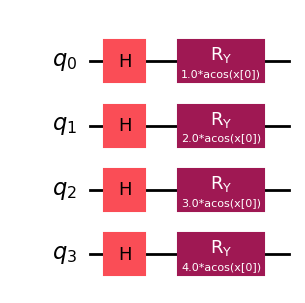

In [10]:
circuit = ChebyshevTower(num_qubits=4, num_features=1, num_chebyshev=4, num_layers=1)
circuit.draw("mpl")

Now, we can easily create the Projected Quantum Kernel object that will be used to compute the kernel matrix.

In [12]:
pqk = ProjectedQuantumKernel(executor=executor, encoding_circuit=circuit)

We proceed to define the ODE to be solved, 

\begin{equation}
\frac{df(x)}{dx} - \lambda e^{-\lambda x k} \sin(\lambda x) - \lambda k f(x) = 0
\end{equation}


We create the homogeneous differential equation to be used using a sympy symbolic expression


In [46]:
x, f, dfdx = sp.symbols("x f dfdx")
lamb, k = 10, 0.4
eq = dfdx - (-lamb * sp.exp(-lamb * x * k) * sp.sin(lamb * x) - lamb * k * f)
initial_values = [1]
eq

dfdx + 4.0*f + 10*exp(-4.0*x)*sin(10*x)

Now we need to create an instance of `ODELoss`, the symbols involved in the ODE must be provided in the correct order: independent variable, function, and higher orders

In [47]:
loss_ODE_squ = ODELoss(
    eq,
    symbols_involved_in_ODE=[x, f, dfdx],
    initial_values=initial_values,
    boundary_handling="pinned",
    eta=0.02
)

An instance of `KernelOptimizer` is created. The instance takes the kernel of choice, the loss function, the optimizer and initial ansatz parameter

In [48]:
x_space = np.linspace(0, 0.9, 25).reshape(-1, 1)
labels = np.zeros((len(x_space), 1))
parameter_values = np.random.rand(len(x_space)+1)

kernel_optimizer = KernelOptimizer(
    pqk,
    loss_ODE_squ,
    optimizer=LBFGSB(),  #Adam({"num_iter":2000, "lr": 0.05, "tol": 1e-10}),
    initial_parameters = parameter_values
)

model = QKODE(quantum_kernel=kernel_optimizer)
model.fit(x_space, labels)

QKODE(quantum_kernel=<squlearn.kernel.matrix.kernel_optimizer.KernelOptimizer object at 0x0000021C9C535A20>)

### Evaluation

Let's print the optimal parameters of the QK ansatz and operator

In [44]:
kernel_optimizer.get_optimal_parameters()

array([ -1.53114615,  15.67181684,  -8.38108131, -12.28762557,
        -0.81674345,   9.91794143,   7.5079534 ,  -4.08300137,
        -8.02817578,  -0.81561917,   6.25751331,   4.38351572,
        -3.51148682,  -4.6224282 ,   1.52115281,   5.10851936,
        -0.13980149,  -4.13712305,   0.23446736,   4.42303329,
        -0.78298576,  -3.04517793,   2.70067606,   1.67323077,
        -2.88028947,   2.67383115])

Text(0, 0.5, 'f')

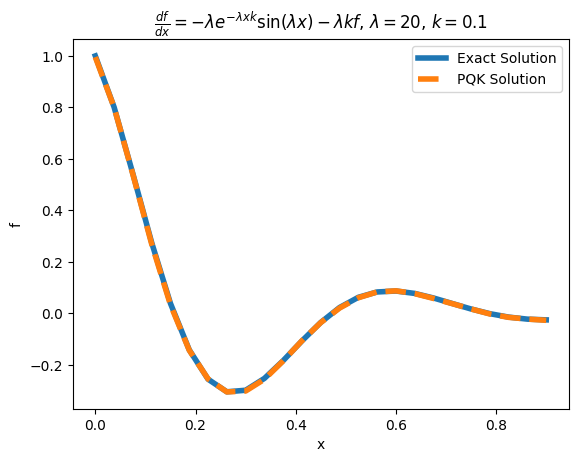

In [49]:
plt.plot(x_space, np.exp(-10 * x_space * 0.4) * np.cos(10 * x_space), label = "Exact Solution", linewidth=4)
plt.plot(x_space, model.predict(x_space), label = "PQK Solution", linewidth=4, linestyle="--")
plt.legend()
plt.title(r"$\frac{df}{dx} = -\lambda e^{-\lambda x k} \sin(\lambda x) - \lambda k f$, $\lambda = 20$, $k = 0.1$")
plt.xlabel("x")
plt.ylabel("f")